# Handwritten Digit Analysis using PCA and Logistic Regression

In this notebook, I am working with handwritten digit images from `0` to `9`.  
Each image is stored as numbers, and I will use PCA to reduce the number of features so the data becomes easier to understand and visualize.

I will also train Logistic Regression models to check how PCA affects prediction accuracy.


## Purpose of this Notebook

The main purpose of this notebook is to understand how PCA helps with dimensionality reduction.

In simple words, each digit image has 64 pixel values because it is an 8 × 8 image. It is hard to visualize 64 features directly, so PCA helps convert those 64 features into a smaller number of new features called principal components.

In this notebook, I will:

- load and understand the handwritten digits dataset
- visualize a few digit images
- apply PCA for 2D and 3D visualization
- train Logistic Regression without PCA
- train Logistic Regression with PCA
- compare model accuracy using different numbers of PCA components
- write a final conclusion based on the results


## 1. Import Libraries

First, I import all the libraries that are needed for data handling, visualization, PCA, model training, and evaluation.


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Dataset and preprocessing
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PCA and machine learning model
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Load the Dataset

Here I load the handwritten digits dataset from Scikit-learn.  
The dataset contains small 8 × 8 images of digits from 0 to 9.

`X` contains the pixel values, and `y` contains the actual digit labels.


In [2]:
# Load the digits dataset
# X contains image pixel values and y contains the digit labels
X, y = load_digits(return_X_y=True)

# Check the shape of the dataset
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (1797, 64)
Shape of y: (1797,)


### Comment

There are 1,797 digit images in this dataset.  
Each image has 64 features, because every image is an 8 × 8 grid of pixel values.


## 3. Lets visualize One Digit Image first

Before applying PCA, I want to see what one digit image looks like.  
Since each image has 64 values, I reshape it back into an 8 × 8 image.


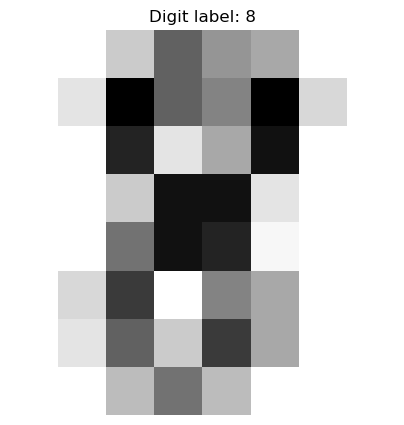

In [6]:
# Select one image from the dataset
image_index = 404

# Display the selected image as an 8 x 8 picture
plt.figure(figsize=(5, 5))
plt.imshow(X[image_index].reshape(8, 8), cmap="Greys")
plt.title(f"Digit label: {y[image_index]}")
plt.axis("off")
plt.show()


### Comment

This step helps me understand that the dataset is made of image-like data, even though it is stored as rows and columns of numbers.


## 4. Lets now visualize a Few More Digit Images

Now I display a few images together so that it is easier to see the variety in handwriting styles.


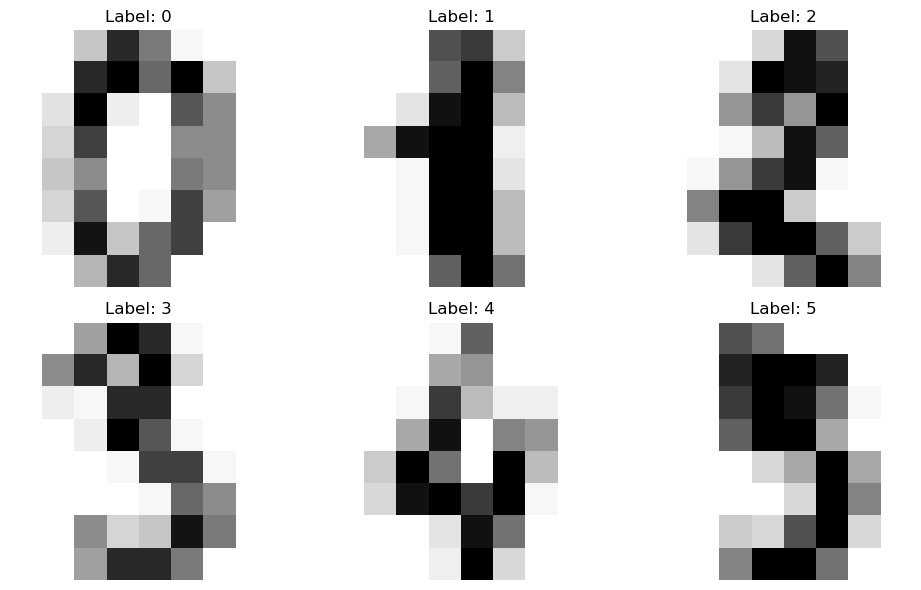

In [7]:
# Create a 2 x 3 grid to show six digit images
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))

# Flatten the axes array so it is easier to loop through
axes = axes.flatten()

# Show the first six images from the dataset
for i in range(6):
    axes[i].imshow(X[i].reshape(8, 8), cmap="Greys")
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


### My comment

Each digit image has the same size, but the shapes are slightly different because may be handwriting varies from person to person.


## 5. Now, lets apply PCA for 2D Visualization

Here I apply PCA and use the first two principal components: `PCA1` and `PCA2`.

This does not use all 64 features directly. Instead, PCA creates new summary features that capture important patterns from the original pixel values.


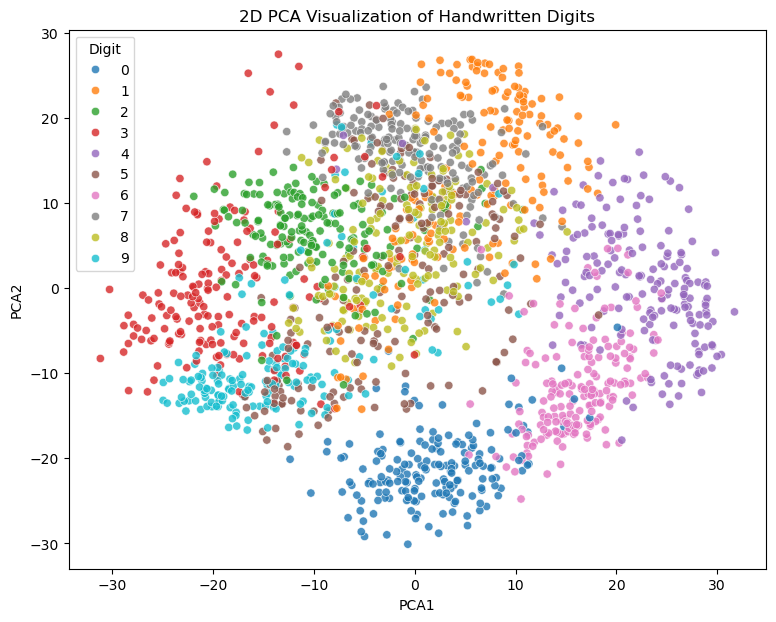

In [8]:
# Apply PCA on the original 64 pixel features
pca_full = PCA()
X_pca = pca_full.fit_transform(X)

# Create a DataFrame using the first two PCA components
pca_2d_data = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Digit": y
})

# Plot PCA1 vs PCA2
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_2d_data,
    x="PCA1",
    y="PCA2",
    hue="Digit",
    palette="tab10",
    alpha=0.8
)
plt.title("2D PCA Visualization of Handwritten Digits")
plt.show()


This 2D plot gives a simple visual idea of how the digit images are grouped.  
Some digits separate better than others, while a few overlap because their handwriting patterns can look similar.

## 6. Now lets apply PCA for 3D Visualization

Now I use the first three principal components: `PCA1`, `PCA2`, and `PCA3`.

The 3D plot gives one extra direction compared with the 2D plot, so it can show the structure of the data a little better.


In [9]:
# To create a DataFrame using the first three PCA components
pca_3d_data = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "PCA3": X_pca[:, 2],
    "Digit": y.astype(str)
})

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    pca_3d_data,
    x="PCA1",
    y="PCA2",
    z="PCA3",
    color="Digit",
    title="3D PCA Visualization of Handwritten Digits"
)

fig.show()


### My comment

In this plot, each point represents one digit image.  
Points close to each other have similar pixel patterns, and points far apart are more different.

The first three PCA components are mainly useful for visualization, not for getting the highest model accuracy.


Lets model this

## 7. Train-Test Split and Feature Scaling

Before training the model, I split the data into training and testing sets.

I also scale the features using `StandardScaler`. Scaling is important because Logistic Regression works better when features are on a similar scale.


In [11]:
# To split the dataset into training and testing data
# stratify=y keeps the digit class distribution similar in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=22,
    stratify=y
)

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data only, then transform both train and test data
# This avoids data leakage from the test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Training data shape: (1437, 64)
Testing data shape: (360, 64)




The model will learn from the training data and will be evaluated on the test data.  
This will give a fair idea of how the model performs on unseen data.


## 8. Logistic Regression Without PCA

First, I train Logistic Regression using all 64 original features.

This is my baseline model. Later, I will compare PCA-based models against this result.


In [12]:
# To create Logistic Regression model
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# Train the model using all 64 scaled features
log_reg.fit(X_train_scaled, y_train)

# Predict the test data
y_pred = log_reg.predict(X_test_scaled)

# Calculate accuracy
accuracy_without_pca = accuracy_score(y_test, y_pred)

# Show results
print("Logistic Regression WITHOUT PCA")
print("Accuracy:", round(accuracy_without_pca, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression WITHOUT PCA
Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        37
           2       1.00      1.00      1.00        35
           3       0.97      0.92      0.94        37
           4       1.00      1.00      1.00        36
           5       0.95      0.97      0.96        36
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.94      0.91      0.93        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.97       360
weighted avg       0.98      0.97      0.97       360


Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  1  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  2  0  0  0  1]
 [ 0  0  0  0 36

### Comment

This model uses all the available pixel features, so it has the most information.  
This result will help me understand how much accuracy changes after applying PCA.


## 9. Logistic Regression with PCA1, PCA2, and PCA3

Now I train Logistic Regression using only the first three PCA components.

This is a very small version of the data, so I expect the accuracy to drop. But this step is useful because it shows the difference between PCA for visualization and PCA for prediction.


In [13]:
# To apply PCA with only 3 components
pca_3 = PCA(n_components=3)

# Fit PCA on training data and transform it
X_train_pca_3 = pca_3.fit_transform(X_train_scaled)

# Transform test data using the same PCA object
X_test_pca_3 = pca_3.transform(X_test_scaled)

# Create DataFrames with clear column names
X_train_pca_3_df = pd.DataFrame(X_train_pca_3, columns=["PCA1", "PCA2", "PCA3"])
X_test_pca_3_df = pd.DataFrame(X_test_pca_3, columns=["PCA1", "PCA2", "PCA3"])

# Train Logistic Regression using only PCA1, PCA2, and PCA3
log_reg_pca_3 = LogisticRegression(max_iter=5000, random_state=42)
log_reg_pca_3.fit(X_train_pca_3_df, y_train)

# Predict test labels
y_pred_pca_3 = log_reg_pca_3.predict(X_test_pca_3_df)

# Calculate accuracy
accuracy_with_pca_3 = accuracy_score(y_test, y_pred_pca_3)

# Show results
print("Logistic Regression WITH PCA1, PCA2, PCA3")
print("Accuracy:", round(accuracy_with_pca_3, 4))
print("Explained Variance Ratio:", pca_3.explained_variance_ratio_)
print("Total Variance Captured:", round(pca_3.explained_variance_ratio_.sum(), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pca_3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_pca_3))


Logistic Regression WITH PCA1, PCA2, PCA3
Accuracy: 0.6972
Explained Variance Ratio: [0.12032984 0.0953676  0.08290227]
Total Variance Captured: 0.2986

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.61      0.68      0.64        37
           2       0.82      0.89      0.85        35
           3       0.61      0.62      0.61        37
           4       0.97      0.97      0.97        36
           5       0.06      0.03      0.04        36
           6       0.97      0.97      0.97        36
           7       0.71      0.83      0.77        36
           8       0.32      0.20      0.25        35
           9       0.53      0.78      0.63        36

    accuracy                           0.70       360
   macro avg       0.66      0.70      0.67       360
weighted avg       0.66      0.70      0.67       360


Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 25  4 

### My comment

Using only three PCA components makes the data easy to plot in 3D, but it removes a lot of useful information.  
That is why PCA1, PCA2, and PCA3 are better for visualization than for final classification.


## 10. Now, lets compare Baseline Model with 3-Component PCA Model

Here I compare the accuracy of the full-feature model with the PCA1–PCA3 model.


In [14]:
# Create a simple comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression without PCA",
        "Logistic Regression with PCA1, PCA2, PCA3"
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca_3
    ]
})

comparison


,Model,Accuracy
0,Logistic Regression without PCA,0.975000
1,"Logistic Regression with PCA1, PCA2, PCA3",0.697222


### My comment

The model without PCA performs better because it uses all 64 features.  
The 3-component PCA model has lower accuracy because it keeps only a small part of the total information.


## 11. PCA Component Comparison

Instead of using only 3 PCA components, I now test different numbers of components.

This helps me see how accuracy changes as PCA keeps more information from the original data.


In [15]:
# To create an empty list to store PCA experiment results
pca_results = []

# Try different numbers of PCA components
# Lower components = more compression, but more information loss
# Higher components = less compression, but more information is retained
for n in [3, 4, 5, 10, 20, 30, 40, 50, 64]:

    # Create PCA object with n components
    pca = PCA(n_components=n)

    # Fit PCA on training data and transform training data
    X_train_pca = pca.fit_transform(X_train_scaled)

    # Transform test data using the same PCA object
    # This prevents data leakage
    X_test_pca = pca.transform(X_test_scaled)

    # Train Logistic Regression on PCA-transformed data
    model = LogisticRegression(max_iter=5000, random_state=42)
    model.fit(X_train_pca, y_train)

    # Predict test labels
    y_pred = model.predict(X_test_pca)

    # Store results for this PCA setting
    pca_results.append({
        "PCA Components": n,
        "Variance Captured": round(pca.explained_variance_ratio_.sum(), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    })

# Convert results into a DataFrame
pca_comparison = pd.DataFrame(pca_results)

# Display the comparison table
pca_comparison


,PCA Components,Variance Captured,Accuracy
0,3,0.2986,0.6972
1,4,0.3655,0.7972
2,5,0.4134,0.8222
3,10,0.5901,0.8917
4,20,0.7966,0.9583
5,30,0.8963,0.9667
6,40,0.9522,0.9694
7,50,0.9832,0.9778
8,64,1.0000,0.9750


This table shows the tradeoff between reducing features and keeping model performance.  
As the number of PCA components increases, the model usually gets more information and the accuracy improves.

## 12. PCA with 95% Variance

Now I let PCA automatically choose the number of components needed to preserve 95% of the variance.

This is a practical way to reduce the feature count while still keeping most of the useful information.


In [16]:
# Lets create PCA object that keeps 95% of the variance
pca_95 = PCA(n_components=0.95)

# Fit PCA on training data and transform it
X_train_pca_95 = pca_95.fit_transform(X_train_scaled)

# Transform test data using the same PCA transformation
X_test_pca_95 = pca_95.transform(X_test_scaled)

# Train Logistic Regression on the 95% variance PCA data
model_pca_95 = LogisticRegression(max_iter=5000, random_state=42)
model_pca_95.fit(X_train_pca_95, y_train)

# Predict on test data
y_pred_pca_95 = model_pca_95.predict(X_test_pca_95)

# Calculate accuracy
accuracy_pca_95 = accuracy_score(y_test, y_pred_pca_95)

# Display final PCA 95% result
print("Number of PCA components for 95% variance:", pca_95.n_components_)
print("Accuracy with 95% PCA:", round(accuracy_pca_95, 4))


Number of PCA components for 95% variance: 40
Accuracy with 95% PCA: 0.9694


### My comment

The 95% variance PCA model reduces the number of features but still keeps strong accuracy.  
This is a better PCA choice for modeling compared with using only PCA1, PCA2, and PCA3.


## 13. Final Results Summary


The baseline Logistic Regression model used all 64 original pixel features and achieved the highest accuracy.

The PCA1, PCA2, and PCA3 model was useful for 3D visualization, but it had lower accuracy because only three components do not capture enough information for strong classification.

The 95% variance PCA model gave a better balance. It reduced the number of features while still keeping most of the important information and maintaining strong classification performance.


In [17]:
# To create final summary table
final_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression without PCA",
        "Logistic Regression with PCA1, PCA2, PCA3",
        "Logistic Regression with 95% variance PCA"
    ],
    "Features / Components Used": [
        64,
        3,
        pca_95.n_components_
    ],
    "Accuracy": [
        round(accuracy_without_pca, 4),
        round(accuracy_with_pca_3, 4),
        round(accuracy_pca_95, 4)
    ]
})

final_summary


,Model,Features / Components Used,Accuracy
0,Logistic Regression without PCA,64,0.9750
1,"Logistic Regression with PCA1, PCA2, PCA3",3,0.6972
2,Logistic Regression with 95% variance PCA,40,0.9694



## Final Conclusion

In this notebook, I used PCA to understand, visualize, and reduce the handwritten digit dataset. Each digit image originally had 64 pixel features, which are difficult to visualize directly. PCA helped convert these features into fewer principal components.

The first two or three PCA components were useful for 2D and 3D visualization. However, using only 3 PCA components captured 30.04% of the variance and achieved 69.17% accuracy, so they were not enough for strong classification performance.

For prediction, using more PCA components worked better. With 40 PCA components, the model captured 95.16% of the variance and achieved 95.28% accuracy. The full 64-feature Logistic Regression model performed best with 97.22% accuracy, but PCA with 40 components gave a good balance between reducing features and maintaining performance.

Overall, this project helped me understand how PCA can be used both for visualizing high-dimensional data and for reducing dimensionality before machine learning.
